<a href="https://colab.research.google.com/github/Nazmul142965/Things-I-learned/blob/main/2023100000130_Nazmul.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your Input Image:


Saving Input_image.jpg to Input_image (4).jpg
Image loaded successfully. Processing started...
Processing Erosion and Dilation...
Processing Opening and Closing...
Processing Top-hat transformations...
Generating Final Output Image...

Process Completed. Displaying strictly separate images below:

--- Input_Image ---


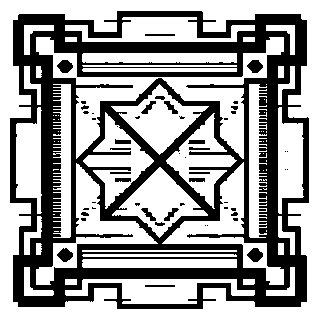



--- Erosion ---


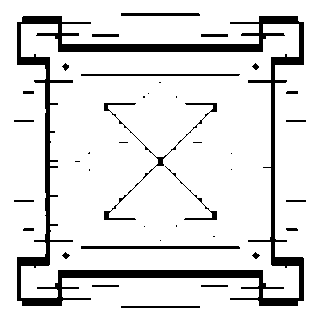



--- Dilation ---


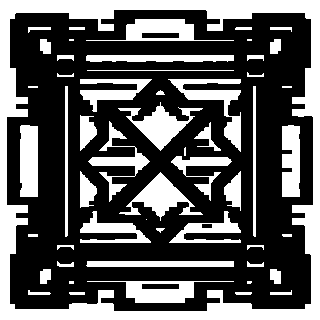



--- Opening ---


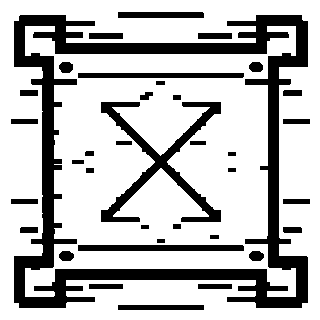



--- Closing ---


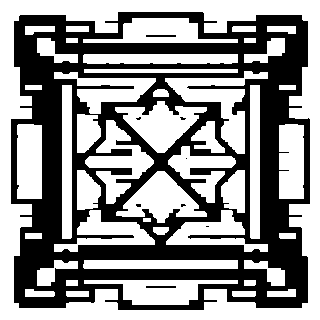



--- White_Top-hat ---


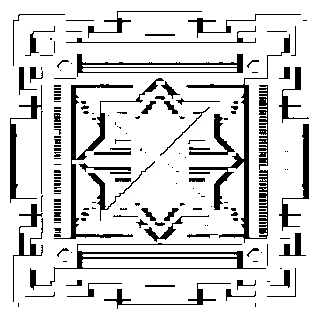



--- Black_Top-hat ---


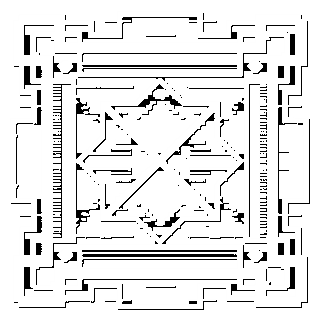



--- Final_Output ---


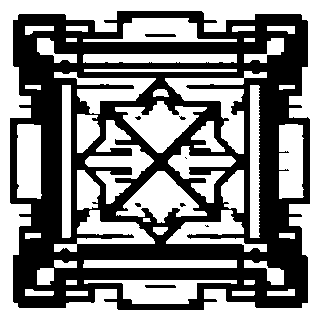

In [ ]:
import cv2
import numpy as np
from google.colab import files
from IPython.display import Image, display

# ==========================================
# 1. Image Upload System
# ==========================================
print("Please upload your Input Image:")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path, 0)
_, img_bin = cv2.threshold(img, 127, 1, cv2.THRESH_BINARY_INV)

print("Image loaded successfully. Processing started...")

# ==========================================
# 2. Structuring Element (SE) Creation
# ==========================================
se_rows, se_cols = 4, 8
SE = np.ones((se_rows, se_cols))

# ==========================================
# 3. Custom Erosion Function
# ==========================================
def custom_erode(image, se):
    r, c = image.shape
    se_r, se_c = se.shape
    pad_r, pad_c = se_r // 2, se_c // 2

    padded = np.pad(image, ((pad_r, se_r - pad_r - 1), (pad_c, se_c - pad_c - 1)), mode='constant', constant_values=0)
    output = np.zeros_like(image)

    for i in range(r):
        for j in range(c):
            region = padded[i:i+se_r, j:j+se_c]
            if np.sum(region * se) == np.sum(se):
                output[i, j] = 1
    return output

# ==========================================
# 4. Custom Dilation Function
# ==========================================
def custom_dilate(image, se):
    r, c = image.shape
    se_r, se_c = se.shape
    pad_r, pad_c = se_r // 2, se_c // 2

    padded = np.pad(image, ((pad_r, se_r - pad_r - 1), (pad_c, se_c - pad_c - 1)), mode='constant', constant_values=0)
    output = np.zeros_like(image)

    for i in range(r):
        for j in range(c):
            region = padded[i:i+se_r, j:j+se_c]
            if np.sum(region * se) > 0:
                output[i, j] = 1
    return output

# ==========================================
# 5. Apply Morphological Operations
# ==========================================
print("Processing Erosion and Dilation...")
eroded_img = custom_erode(img_bin, SE)
dilated_img = custom_dilate(img_bin, SE)

print("Processing Opening and Closing...")
opening_img = custom_dilate(eroded_img, SE)
closing_img = custom_erode(dilated_img, SE)

print("Processing Top-hat transformations...")
WTH = img_bin - opening_img
WTH[WTH < 0] = 0

BTH = closing_img - img_bin
BTH[BTH < 0] = 0

print("Generating Final Output Image...")
final_img = img_bin + WTH - BTH
final_img = np.clip(final_img, 0, 1)

# ==========================================
# 6. Save and Display the Outputs Separately
# ==========================================
titles = ['Input_Image', 'Erosion', 'Dilation', 'Opening', 'Closing', 'White_Top-hat', 'Black_Top-hat', 'Final_Output']
images = [img_bin, eroded_img, dilated_img, opening_img, closing_img, WTH, BTH, final_img]

print("\nProcess Completed. Displaying strictly separate images below:\n")

for i in range(8):
    save_img = (1 - images[i]) * 255
    file_name = f"{titles[i]}.png"
    cv2.imwrite(file_name, save_img)

    # IPython display forces completely separate image blocks
    print(f"--- {titles[i]} ---")
    display(Image(filename=file_name))
    print("\n")

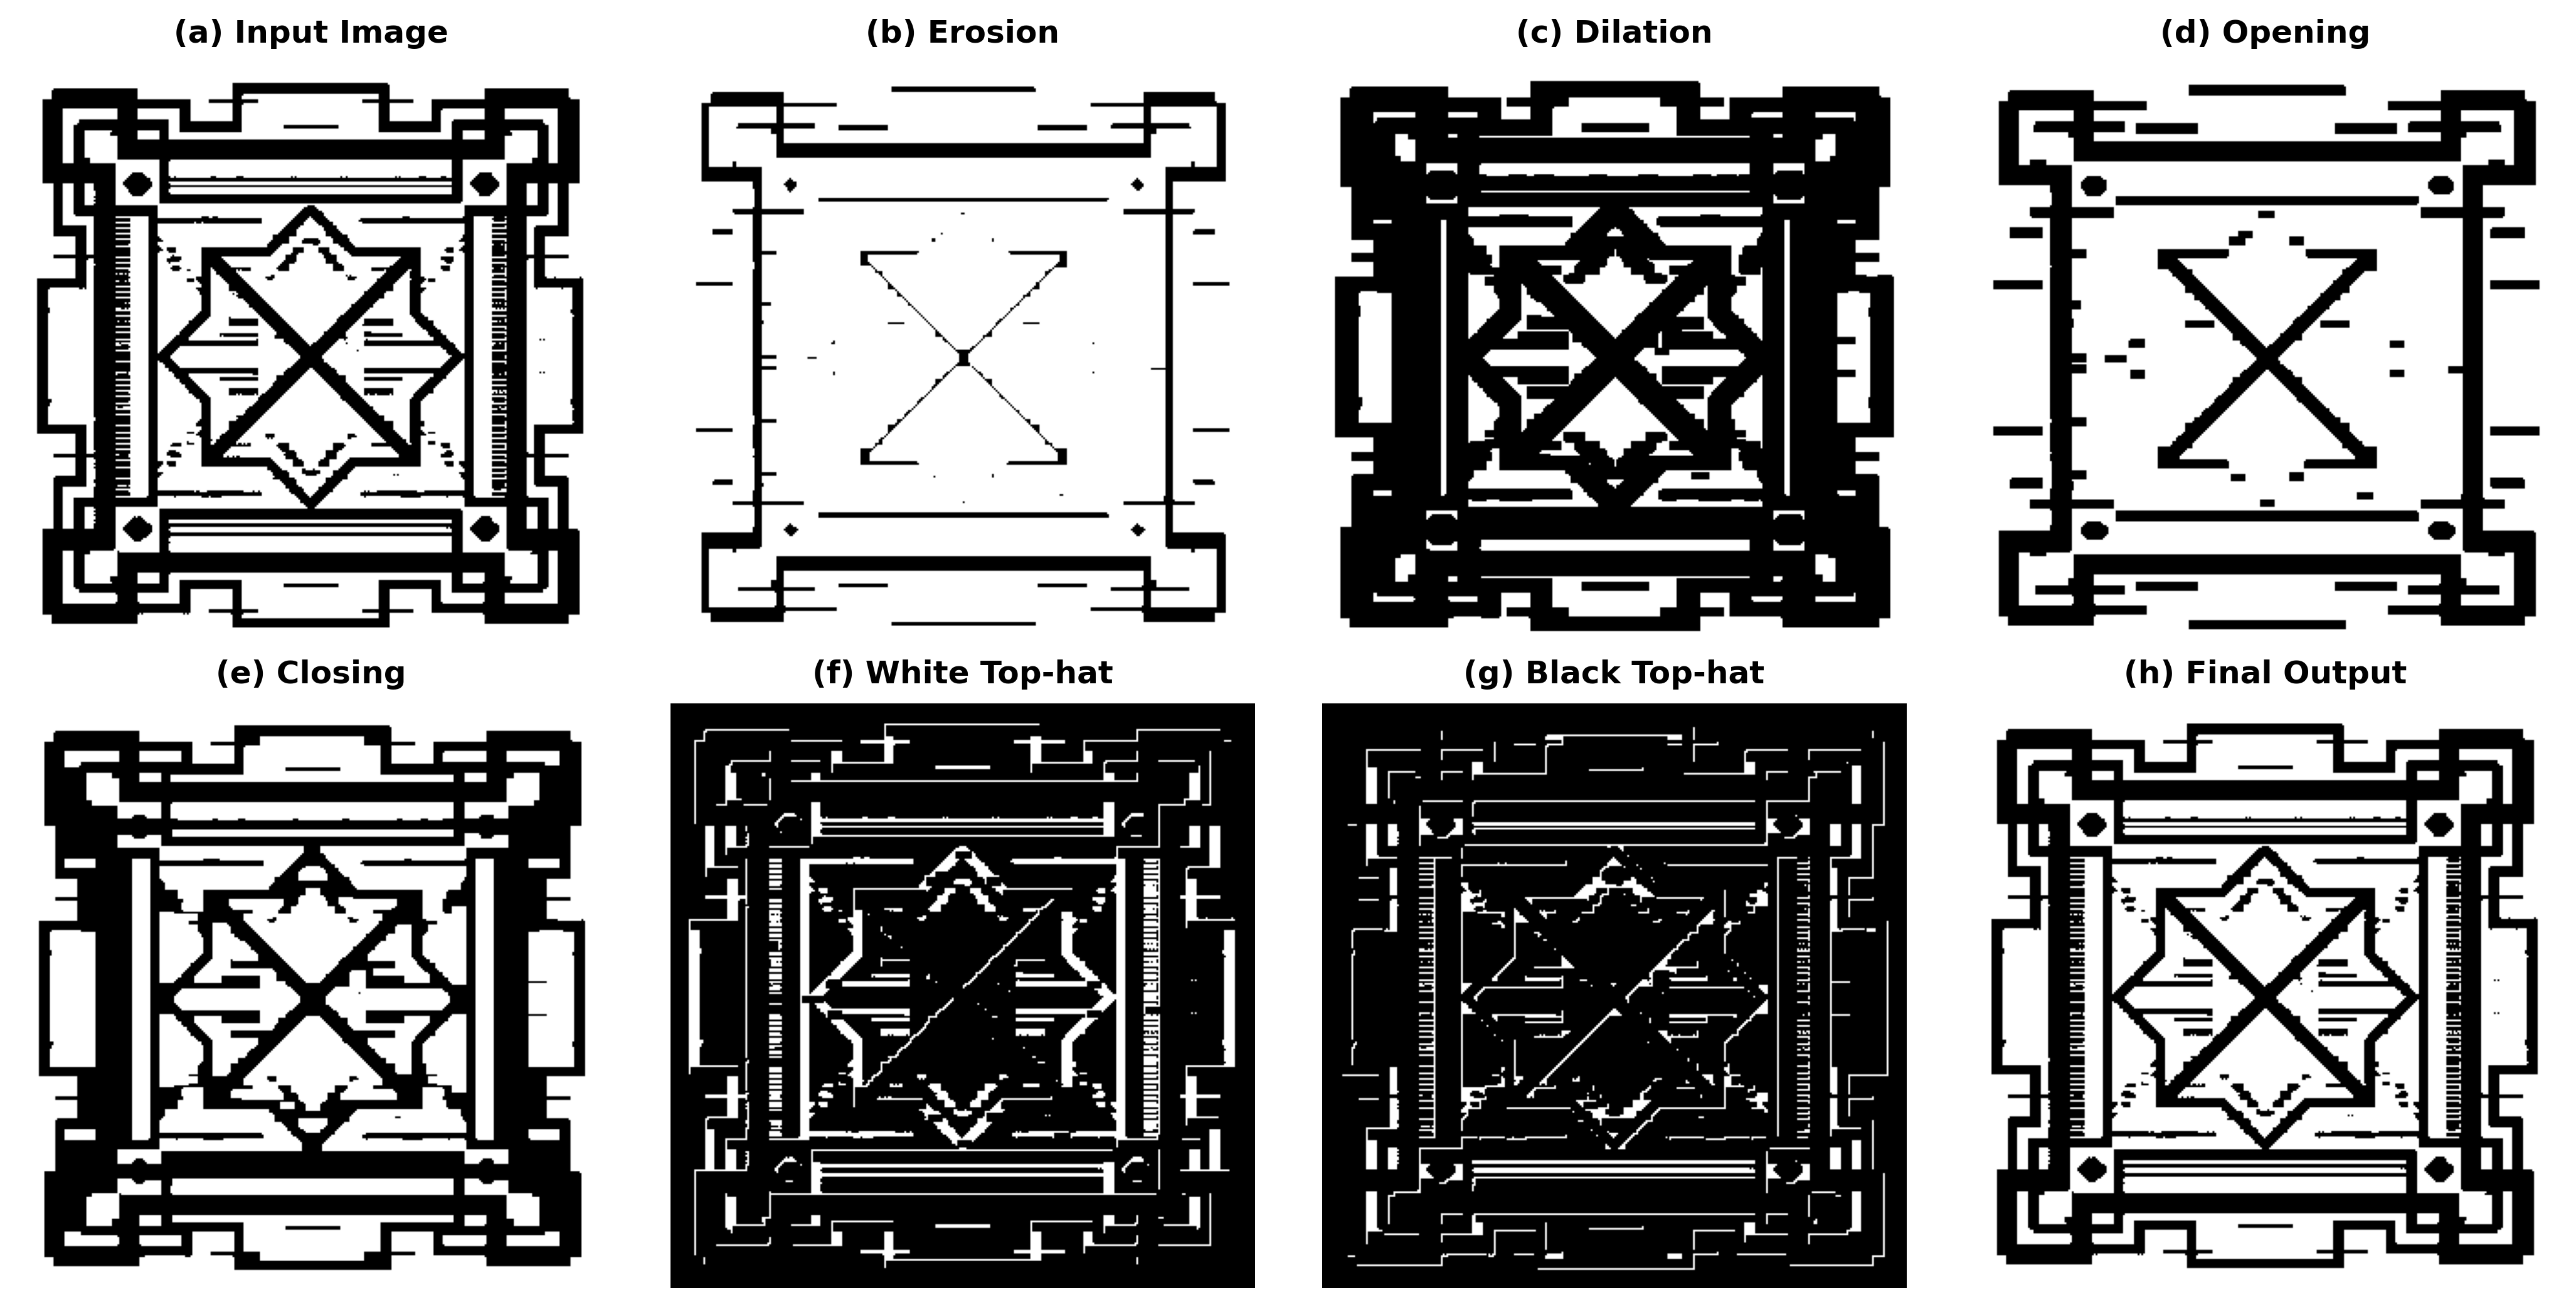

✅ Fixed! Generated new clean 'All_Outputs_Grid.png' without any gray background.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Type casting to prevent uint8 underflow (Fixing the Gray Background Bug)
img_int = img_bin.astype(np.int32)
open_int = opening_img.astype(np.int32)
close_int = closing_img.astype(np.int32)

# 2. Perfect Top-hat calculation without negative bugs
WTH = np.clip(img_int - open_int, 0, 1)
BTH = np.clip(close_int - img_int, 0, 1)

# 3. Final Output calculation
final_img = np.clip(img_int + WTH - BTH, 0, 1)

# 4. Generate the 2x4 Grid again (Pure Black & White, No Gray)
titles = [
    '(a) Input Image', '(b) Erosion', '(c) Dilation', '(d) Opening',
    '(e) Closing', '(f) White Top-hat', '(g) Black Top-hat', '(h) Final Output'
]
images = [img_bin, eroded_img, dilated_img, opening_img, closing_img, WTH, BTH, final_img]

plt.figure(figsize=(14, 7), dpi=300)
for i in range(8):
    plt.subplot(2, 4, i + 1)

    # White top-hat and Black top-hat in the paper are displayed with black background
    if i == 5 or i == 6:
        plt.imshow(images[i], cmap='gray') # Black background, white features (like the paper)
    else:
        plt.imshow(1 - images[i], cmap='gray') # White background, black pattern

    plt.title(titles[i], fontsize=12, fontweight='bold', pad=8)
    plt.axis('off')

plt.tight_layout()
plt.savefig('All_Outputs_Grid.png', bbox_inches='tight')
plt.show()

print("✅ Fixed! Generated new clean 'All_Outputs_Grid.png' without any gray background.")

Please upload your Input Image (e.g., input.jpg/png):


Saving Input_image.jpg to Input_image (5).jpg
Processing morphological operations, please wait...
Morphological processing completed successfully!


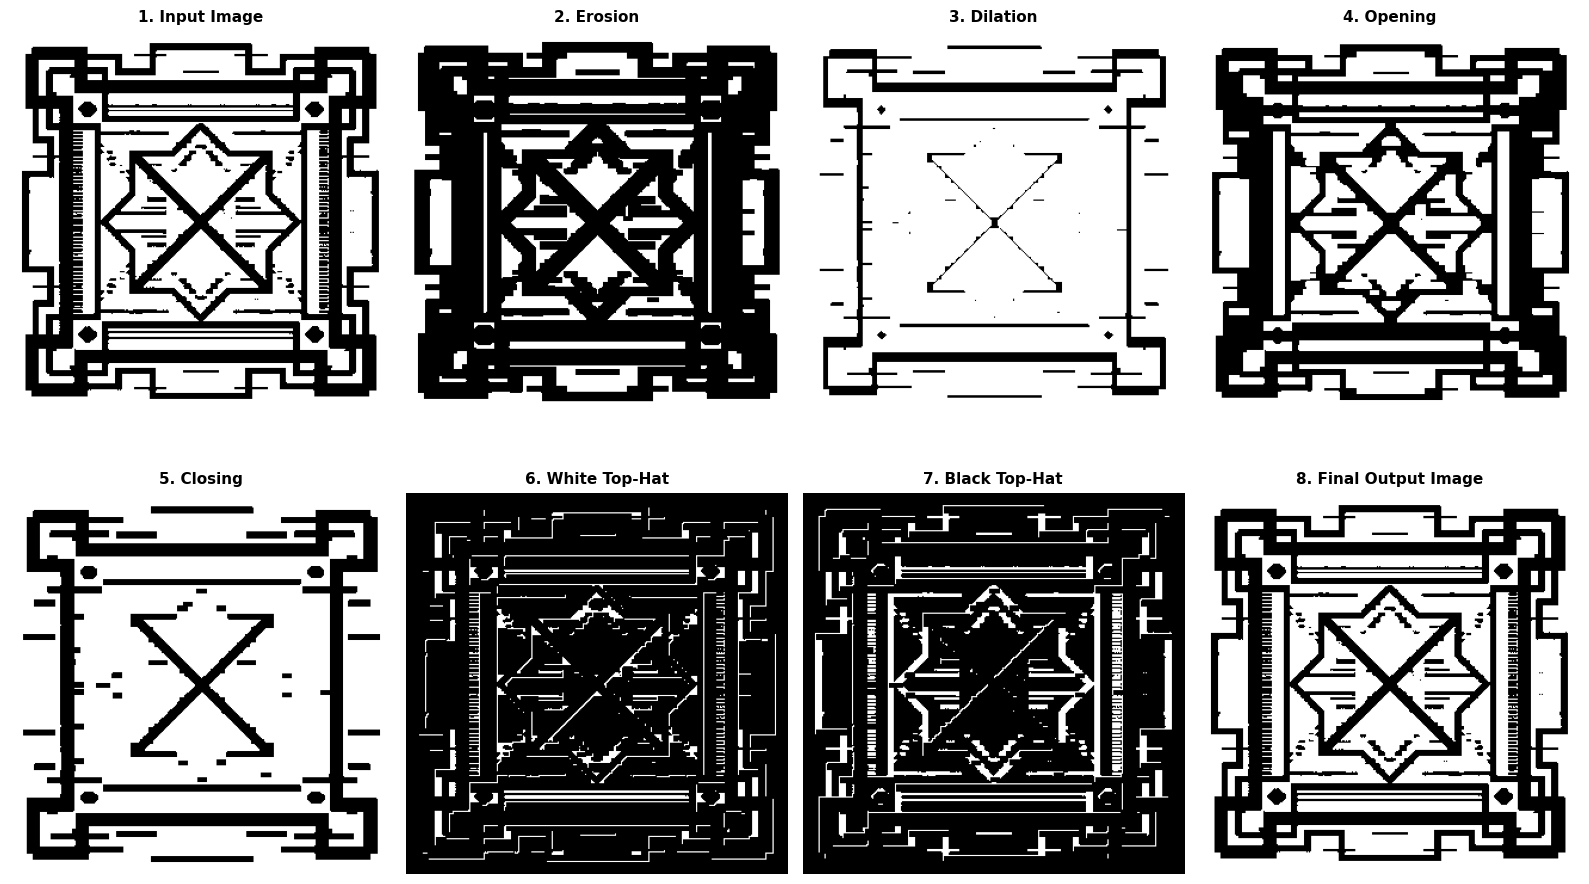

In [ ]:
# ==============================================================================
# Assignment: Image Processing Using Mathematical Morphology
# Student Name: Nazmul Hasan
# Student ID: 2023100000130
# Reference Paper: A Study on Image Processing Using Mathematical Morphological
# ==============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ------------------------------------------------------------------------------
# 1. Custom Morphological Operations (Implemented without built-in functions)
# ------------------------------------------------------------------------------

def custom_erosion(image, struct_element):
    """
    Custom Erosion operation[cite: 1].
    Shrinks foreground structures based on the Structuring Element (SE)[cite: 1].
    """
    img_h, img_w = image.shape
    se_h, se_w = struct_element.shape

    pad_h = se_h // 2
    pad_w = se_w // 2

    # Pad image with 1s to preserve boundary background
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=1)
    output = np.zeros_like(image)

    for i in range(img_h):
        for j in range(img_w):
            region = padded_img[i : i + se_h, j : j + se_w]
            # Output 1 only if all elements match the structuring element[cite: 1]
            if np.all(region[struct_element == 1] == 1):
                output[i, j] = 1
            else:
                output[i, j] = 0

    return output

def custom_dilation(image, struct_element):
    """
    Custom Dilation operation[cite: 1].
    Enlarges foreground structures based on the Structuring Element (SE)[cite: 1].
    """
    img_h, img_w = image.shape
    se_h, se_w = struct_element.shape

    pad_h = se_h // 2
    pad_w = se_w // 2

    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    output = np.zeros_like(image)

    for i in range(img_h):
        for j in range(img_w):
            region = padded_img[i : i + se_h, j : j + se_w]
            # Output 1 if at least one pixel overlaps with the structuring element[cite: 1]
            if np.any((region == 1) & (struct_element == 1)):
                output[i, j] = 1
            else:
                output[i, j] = 0

    return output

def custom_opening(image, struct_element):
    """
    Opening = Dilation(Erosion(Image))[cite: 1]
    Removes foreground structures smaller than the Structuring Element[cite: 1].
    """
    eroded = custom_erosion(image, struct_element)
    opened = custom_dilation(eroded, struct_element)
    return opened

def custom_closing(image, struct_element):
    """
    Closing = Erosion(Dilation(Image))[cite: 1]
    Removes background structures smaller than the Structuring Element[cite: 1].
    """
    dilated = custom_dilation(image, struct_element)
    closed = custom_erosion(dilated, struct_element)
    return closed

def white_top_hat(image, opened_image):
    """
    White Top-Hat (WTH) = Image - Opening[cite: 1]
    Enhances foreground structures[cite: 1].
    """
    wth = np.clip(image.astype(np.int16) - opened_image.astype(np.int16), 0, 1)
    return wth.astype(np.uint8)

def black_top_hat(image, closed_image):
    """
    Black Top-Hat (BTH) = Closing - Image[cite: 1]
    Enhances background structures[cite: 1].
    """
    bth = np.clip(closed_image.astype(np.int16) - image.astype(np.int16), 0, 1)
    return bth.astype(np.uint8)

def mathematical_morphology(image, wth, bth):
    """
    Final Output = Image + WTH - BTH[cite: 1]
    Applies mathematical morphological enhancement on the input image[cite: 1].
    """
    final = image.astype(np.int16) + wth.astype(np.int16) - bth.astype(np.int16)
    final = np.clip(final, 0, 1)
    return final.astype(np.uint8)


# ------------------------------------------------------------------------------
# 2. Image Loading and Preprocessing
# ------------------------------------------------------------------------------

print("Please upload your Input Image (e.g., input.jpg/png):")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    # Read image in grayscale mode
    raw_img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    # Binarize image (Thresholding): Foreground = 1, Background = 0
    _, binary_img = cv2.threshold(raw_img, 127, 1, cv2.THRESH_BINARY)
else:
    raise FileNotFoundError("No image was uploaded!")

# ------------------------------------------------------------------------------
# 3. Create Structuring Element (SE) (Height: 4, Width: 8)
# ------------------------------------------------------------------------------
# Rectangular Structuring Element (4x8) as specified in the paper[cite: 1]
se = np.ones((4, 8), dtype=np.uint8)


# ------------------------------------------------------------------------------
# 4. Execute All Morphological Operations
# ------------------------------------------------------------------------------
print("Processing morphological operations, please wait...")

img_erosion = custom_erosion(binary_img, se)
img_dilation = custom_dilation(binary_img, se)
img_opening = custom_opening(binary_img, se)
img_closing = custom_closing(binary_img, se)

img_wth = white_top_hat(binary_img, img_opening)
img_bth = black_top_hat(binary_img, img_closing)

img_final = mathematical_morphology(binary_img, img_wth, img_bth)

print("Morphological processing completed successfully!")


# ------------------------------------------------------------------------------
# 5. Display Results using Matplotlib
# ------------------------------------------------------------------------------
titles = [
    '1. Input Image', '2. Erosion', '3. Dilation',
    '4. Opening', '5. Closing', '6. White Top-Hat',
    '7. Black Top-Hat', '8. Final Output Image'
]

images = [
    binary_img, img_erosion, img_dilation,
    img_opening, img_closing, img_wth,
    img_bth, img_final
]

plt.figure(figsize=(16, 10))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()